# Prepare London MSOA boundaries

In this notebook, the 2021 MSOA (Middle Layer Super Output Area) boundaries are prepared for Greater London so that the geographical aspects of the project can be handled using this dataset. The FHRS establishments as well as other data related to population, transport and access will be joined using each MSOA code.

In [1]:
from pathlib import Path

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
RAW_MSOA_FOLDER = Path("../data/spatial/raw/msoa2021")
RAW_MSOA_FOLDER.mkdir(parents=True, exist_ok=True)

PROCESSED_SPATIAL_FOLDER = Path("../data/spatial/processed")
PROCESSED_SPATIAL_FOLDER.mkdir(parents=True, exist_ok=True)

print(f"Raw MSOA folder: {RAW_MSOA_FOLDER}")
print(f"Processed spatial folder: {PROCESSED_SPATIAL_FOLDER}")

Raw MSOA folder: ..\data\spatial\raw\msoa2021
Processed spatial folder: ..\data\spatial\processed


# Loading London MSOA dataset in one combined dataframe

The downloaded dataset currently has each borough's data in seperate files, by collating these it will allow us to do row by row allocation easier with the bakery dataset. Furthermore this is a good place to take a look at the dataset, including the coordinate reference system and column names which will be important as we continue to code.

In [3]:
msoa_files = []

for file_name in os.listdir(RAW_MSOA_FOLDER):
    if file_name.endswith(".shp"):
        file_path = (RAW_MSOA_FOLDER/ file_name)
        msoa_files.append(file_path)


print(f"MSOA files found: {len(msoa_files)}")

msoa_datasets = []

for file_path in msoa_files:
    borough_msoa = gpd.read_file(file_path)
    borough_msoa["Borough"] = (file_path.stem)
    msoa_datasets.append(borough_msoa)

london_msoa = gpd.GeoDataFrame(
    pd.concat(msoa_datasets, ignore_index=True),
    crs=msoa_datasets[0].crs
)

print("Total MSOA rows:", len(london_msoa))

print(f"\nCoordinate reference system: {london_msoa.crs}")

print(f"\nColumns: {london_msoa.columns.tolist()}")

london_msoa.sample(5)

MSOA files found: 33
Total MSOA rows: 1002

Coordinate reference system: EPSG:27700

Columns: ['msoa21cd', 'msoa21nm', 'lad22cd', 'lad22nm', 'geometry', 'Borough']


,msoa21cd,msoa21nm,lad22cd,lad22nm,geometry,Borough
87,E02000074,Bexley 010,E09000004,Bexley,"POLYGON ((550816.595 177535.133, 550819.563 17...",Bexley
438,E02000414,Haringey 018,E09000014,Haringey,"POLYGON ((533175.014 190083.65, 533176.756 190...",Haringey
210,E02000206,Croydon 013,E09000008,Croydon,"POLYGON ((533541.513 168150.708, 533542.735 16...",Croydon
441,E02006794,Haringey 037,E09000014,Haringey,"POLYGON ((534016.255 191749.64, 534047.497 191...",Haringey
777,E02000752,Redbridge 002,E09000026,Redbridge,"POLYGON ((548065.625 193806.016, 548071.36 193...",Redbridge


## Clean the London MSOA dataset

Only columns required need to be retained and column headings will be renamed for better readability and comprehension.
The area of each MSOA is also calculated for future use.

In [4]:
london_msoa = london_msoa[["lad22nm", "lad22cd", "msoa21nm", "msoa21cd", "geometry"]].copy()

london_msoa = london_msoa.rename(columns={"lad22nm": "borough_name",
                                          "lad22cd": "borough_code",
                                          "msoa21nm": "msoa_name",
                                          "msoa21cd": "msoa_code"})

london_msoa["area_km2"] = (london_msoa.geometry.area/1000000)

london_msoa.sample(10)

,borough_name,borough_code,msoa_name,msoa_code,geometry,area_km2
649,Lambeth,E09000022,Lambeth 008,E02000625,"POLYGON ((529693.188 176835.297, 529710.75 176...",0.554377
446,Harrow,E09000015,Harrow 001,E02000433,"POLYGON ((517378.5 194090.609, 517382.104 1940...",6.318056
306,Enfield,E09000010,Enfield 035,E02000311,"POLYGON ((531607 192557, 531602.71 192551.851,...",1.417112
208,Croydon,E09000008,Croydon 008,E02000201,"POLYGON ((534470.081 168933.992, 534477.375 16...",0.858845
83,Bexley,E09000004,Bexley 003,E02000067,"POLYGON ((549929.434 179009.134, 549921.238 17...",2.617970
731,Newham,E09000025,Newham 009,E02000722,"POLYGON ((539673.684 185026.158, 539674 185025...",0.452148
27,Barnet,E09000003,Barnet 041,E02000064,"POLYGON ((524731.935 186749.381, 524733.689 18...",0.794376
127,Bromley,E09000006,Bromley 005,E02000131,"POLYGON ((534345.524 171397.696, 534357.76 171...",1.766585
543,Hounslow,E09000018,Hounslow 018,E02000543,"POLYGON ((513839.372 176500.753, 513839.851 17...",1.144326
228,Croydon,E09000008,Croydon 038,E02000231,"POLYGON ((530450.816 162583.676, 530452.382 16...",3.362706


## Validate the cleaned MSOA dataset

Basic checks to confirm each MSOA has a unique code and no geographical information is missing. There should be 1002 MSOAs and 33 boroughs total.

In [5]:
print(f"Total MSOAs: {len(london_msoa)}")
print(f"Duplicate MSOA codes: {london_msoa["msoa_code"].duplicated().sum()}")
print(f"Missing MSOA codes: {london_msoa["msoa_code"].isna().sum()}")
print(f"Missing geometries: {london_msoa["geometry"].isna().sum()}")
print(f"Valid geometries: {(london_msoa["geometry"].is_valid).sum()}")
print(f"Number of boroughs: {london_msoa["borough_code"].nunique()}")

Total MSOAs: 1002
Duplicate MSOA codes: 0
Missing MSOA codes: 0
Missing geometries: 0
Valid geometries: 1002
Number of boroughs: 33


# Display of London MSOA boundaries

Checking that the Greater London MSOA boundaries visually plot correctly from the loaded dataset.

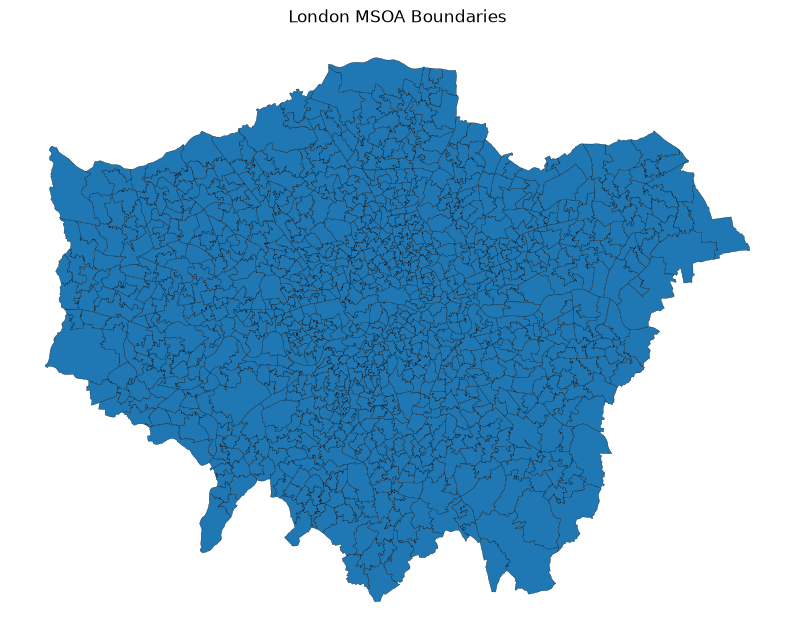

In [6]:
london_msoa.plot(figsize=(10, 10),
                 edgecolor="black",
                 linewidth=0.2)

plt.title("London MSOA Boundaries")
plt.axis("off")
plt.show()

## Save validated and cleaned MSOA dataset

In [7]:
OUTPUT_PATH = (PROCESSED_SPATIAL_FOLDER/ "london_msoa_2021.gpkg")

london_msoa.to_file(OUTPUT_PATH, driver="GPKG", index=False)

print(f"Saved to: {OUTPUT_PATH}")

Saved to: ..\data\spatial\processed\london_msoa_2021.gpkg
